## Análisis exploratorio y preparación de variables

En esta sección se realiza un análisis preliminar del dataset con el objetivo de comprender la distribución de las clases y las características de los datos.

Se calcula el porcentaje de transacciones fraudulentas frente a las normales, lo cual permite evidenciar el fuerte desbalance existente en el problema.

Además, se obtienen estadísticas descriptivas de las variables para analizar su comportamiento general.

Finalmente, se separan las variables independientes (`X`) de la variable objetivo (`y`), paso fundamental para el entrenamiento de los modelos de aprendizaje automático.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/TFG_Backend/data/creditcard.csv")

print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#Isolation Forest

## División del conjunto de datos en entrenamiento y prueba

Se divide el dataset en dos subconjuntos: uno para el entrenamiento del modelo y otro para su evaluación.

Se utiliza un 70% de los datos para entrenamiento y un 30% para prueba. Además, se emplea el parámetro `stratify` para mantener la proporción original de clases en ambos conjuntos, lo cual es especialmente importante debido al desbalance del dataset.

Esta separación permite evaluar el rendimiento del modelo en datos no vistos previamente, evitando así problemas de sobreajuste.

In [ ]:
df["Class"].value_counts(normalize=True) * 100

df.describe()

X = df.drop("Class", axis=1)
y = df["Class"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)




## Entrenamiento del modelo Isolation Forest

Se implementa el algoritmo Isolation Forest, un método de aprendizaje no supervisado diseñado específicamente para la detección de anomalías.

Este modelo se basa en la idea de que las anomalías son más fáciles de aislar que los datos normales mediante particiones aleatorias.

Se configuran parámetros clave como:
- `n_estimators`: número de árboles en el modelo
- `contamination`: proporción estimada de anomalías (fraudes)

El modelo se entrena utilizando únicamente los datos de entrenamiento.

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.0017,  # aprox % fraude
    random_state=42
)

iso.fit(X_train)

IsolationForest(contamination=0.0017, random_state=42)

## Generación y transformación de predicciones

Una vez entrenado el modelo, se generan predicciones sobre el conjunto de prueba.

El algoritmo devuelve valores:
- `-1` para anomalías
- `1` para datos normales

Para facilitar la evaluación, estos valores se transforman a formato binario:
- `1` representa fraude
- `0` representa transacción legítima

In [ ]:
y_pred = iso.predict(X_test)

# Convertimos a 0/1
y_pred = [1 if x == -1 else 0 for x in y_pred]

## Evaluación del modelo Isolation Forest

Se evalúa el rendimiento del modelo mediante la matriz de confusión y el informe de clasificación.

Las métricas principales analizadas son:
- Precisión (Precision)
- Recall (sensibilidad)
- F1-score

Dado el contexto del problema, el recall adquiere especial importancia, ya que es fundamental detectar el mayor número posible de fraudes, incluso a costa de aumentar los falsos positivos.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[85201    94]
 [  111    37]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.28      0.25      0.27       148

    accuracy                           1.00     85443
   macro avg       0.64      0.62      0.63     85443
weighted avg       1.00      1.00      1.00     85443



# Modelo Local Outlier Factor (LOF)

Se implementa el algoritmo Local Outlier Factor (LOF), otro método no supervisado basado en la densidad local de los datos.

Este modelo detecta anomalías comparando la densidad de cada punto con la de sus vecinos más cercanos.

Se utiliza el parámetro `novelty=True` para permitir la predicción sobre nuevos datos (conjunto de test), lo cual no es el comportamiento por defecto.

Posteriormente, se evalúa el modelo utilizando las mismas métricas que en el caso anterior.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=y_train.mean(),
    novelty=True
)

lof.fit(X_train)

y_pred_lof = lof.predict(X_test)

# Convertimos a 0/1
y_pred_lof = [1 if x == -1 else 0 for x in y_pred_lof]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Matriz LOF")
print(confusion_matrix(y_test, y_pred_lof))

print("Reporte LOF")
print(classification_report(y_test, y_pred_lof))

scores_lof = lof.decision_function(X_test)
print("ROC-AUC LOF:", roc_auc_score(y_test, -scores_lof))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Matriz LOF
[[85160   135]
 [  143     5]]
Reporte LOF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.04      0.03      0.03       148

    accuracy                           1.00     85443
   macro avg       0.52      0.52      0.52     85443
weighted avg       1.00      1.00      1.00     85443



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


ROC-AUC LOF: 0.7489371545177863


# Modelo One-Class SVM

Se implementa el algoritmo One-Class SVM, un modelo de aprendizaje no supervisado que intenta aprender la frontera que delimita los datos normales.

Este modelo es especialmente sensible al escalado de las variables, por lo que resulta importante normalizar características como `Time` y `Amount`.

Se evalúa su rendimiento utilizando matriz de confusión, métricas de clasificación y ROC-AUC.

In [ ]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=y_train.mean()
)

ocsvm.fit(X_train)

y_pred_svm = ocsvm.predict(X_test)

# Convertimos a 0/1
y_pred_svm = [1 if x == -1 else 0 for x in y_pred_svm]

print("Matriz One-Class SVM")
print(confusion_matrix(y_test, y_pred_svm))

print("Reporte One-Class SVM")
print(classification_report(y_test, y_pred_svm))

scores_svm = ocsvm.decision_function(X_test)
print("ROC-AUC SVM:", roc_auc_score(y_test, -scores_svm))


Matriz One-Class SVM
[[85127   168]
 [  148     0]]
Reporte One-Class SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.00      0.00      0.00       148

    accuracy                           1.00     85443
   macro avg       0.50      0.50      0.50     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC SVM: 0.48705121969381304


#**Ajuste de umbral de decisión (threshold tuning)**

Se analizan los valores continuos generados por el modelo (scores) para determinar el umbral óptimo de clasificación.

En lugar de utilizar un threshold fijo, se evalúan múltiples valores para observar su impacto en métricas como precisión, recall y F1-score.

Este proceso permite encontrar un equilibrio más adecuado entre detección de fraudes y falsos positivos.

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

scores_iso = iso.decision_function(X_test)

# Convertimos para que valores más altos = más anomalía
scores_iso = -scores_iso


#Crear función para probar thresholds

In [ ]:
def evaluar_thresholds(y_true, scores, n=50):
    thresholds = np.linspace(scores.min(), scores.max(), n)

    resultados = []

    for t in thresholds:
        y_pred = (scores >= t).astype(int)

        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        resultados.append((t, precision, recall, f1))

    return resultados


#Ejecutar análisis

In [ ]:
resultados_iso = evaluar_thresholds(y_test, scores_iso)

# Mostrar los 10 mejores por F1
sorted(resultados_iso, key=lambda x: x[3], reverse=True)[:10]


[(np.float64(0.007224657784525745),
  0.3103448275862069,
  0.24324324324324326,
  0.2727272727272727),
 (np.float64(0.015517597956490548),
  0.3235294117647059,
  0.22297297297297297,
  0.264),
 (np.float64(-0.0010682823874390013),
  0.2781954887218045,
  0.25,
  0.26334519572953735),
 (np.float64(-0.009361222559403803),
  0.2441860465116279,
  0.28378378378378377,
  0.2625),
 (np.float64(0.02381053812845535),
  0.37037037037037035,
  0.20270270270270271,
  0.26200873362445415),
 (np.float64(0.03210347830042015),
  0.417910447761194,
  0.1891891891891892,
  0.26046511627906976),
 (np.float64(-0.017654162731368606),
  0.2107843137254902,
  0.2905405405405405,
  0.24431818181818182),
 (np.float64(-0.025947102903333352),
  0.18972332015810275,
  0.32432432432432434,
  0.23940149625935161),
 (np.float64(-0.034240043075298154),
  0.1716171617161716,
  0.35135135135135137,
  0.23059866962305986),
 (np.float64(-0.04253298324726296),
  0.14893617021276595,
  0.3783783783783784,
  0.2137404580

##5 mejores resultados

In [ ]:
resultados_iso = evaluar_thresholds(y_test, scores_iso)

sorted(resultados_iso, key=lambda x: x[3], reverse=True)[:5]

[(np.float64(0.007224657784525745),
  0.3103448275862069,
  0.24324324324324326,
  0.2727272727272727),
 (np.float64(0.015517597956490548),
  0.3235294117647059,
  0.22297297297297297,
  0.264),
 (np.float64(-0.0010682823874390013),
  0.2781954887218045,
  0.25,
  0.26334519572953735),
 (np.float64(-0.009361222559403803),
  0.2441860465116279,
  0.28378378378378377,
  0.2625),
 (np.float64(0.02381053812845535),
  0.37037037037037035,
  0.20270270270270271,
  0.26200873362445415)]

----------------------
#FASE **2** REENTRENAMIENTO

## Reentrenamiento del modelo con datos escalados

Se aplica un proceso de escalado a las variables `Time` y `Amount` utilizando StandardScaler, con el objetivo de mejorar el rendimiento del modelo.

Posteriormente, se reentrena el modelo Isolation Forest con parámetros ajustados, incluyendo un mayor número de árboles y un mayor número de muestras.

Se evalúa nuevamente el modelo para comparar su rendimiento respecto a la versión inicial.

----------------------

In [ ]:
# ----------------------
# REENTRENAMIENTO
# ----------------------

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1️⃣ Escalado de Time y Amount
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

# 2️⃣ Reentrenar modelo con más árboles y max_samples mayor
iso_tuned = IsolationForest(
    n_estimators=300,
    contamination=y_train.mean(),
    max_samples=10000,
    random_state=42,
    n_jobs=-1
)

iso_tuned.fit(X_train_scaled)

# 3️⃣ Nuevas predicciones
y_pred_tuned = iso_tuned.predict(X_test_scaled)

# Convertir -1 / 1 a 1 / 0
y_pred_tuned = [1 if x == -1 else 0 for x in y_pred_tuned]

# 4️⃣ Evaluación
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# 5️⃣ ROC-AUC
scores_tuned = iso_tuned.decision_function(X_test_scaled)
print("\nROC-AUC:", roc_auc_score(y_test, -scores_tuned))


Matriz de confusión:
[[85202    93]
 [  105    43]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.32      0.29      0.30       148

    accuracy                           1.00     85443
   macro avg       0.66      0.64      0.65     85443
weighted avg       1.00      1.00      1.00     85443


ROC-AUC: 0.9450437511783428


# Optimización avanzada del modelo

Se realiza una optimización más exhaustiva del modelo Isolation Forest, incluyendo:
- Ajuste de hiperparámetros
- Búsqueda de umbral óptimo con restricción de recall
- Evaluación mediante métricas avanzadas

Además, se generan visualizaciones como:
- Matriz de confusión
- Curva Precision-Recall

El objetivo es maximizar la capacidad del modelo para detectar fraudes manteniendo un equilibrio con los falsos positivos.

Top thresholds con Recall >= 0.40:
[(np.float64(-0.05632961573086237), 0.24904214559386972, 0.4391891891891892, 0.31784841075794623), (np.float64(-0.05869767339998627), 0.24253731343283583, 0.4391891891891892, 0.3125), (np.float64(-0.0610657310691102), 0.23465703971119134, 0.4391891891891892, 0.3058823529411765), (np.float64(-0.05396155806173847), 0.24110671936758893, 0.41216216216216217, 0.30423940149625933), (np.float64(-0.0634337887382341), 0.2181208053691275, 0.4391891891891892, 0.2914798206278027)]

Mejor threshold seleccionado:
Threshold: -0.05632961573086237
Precision: 0.24904214559386972
Recall: 0.4391891891891892
F1: 0.31784841075794623

Matriz de confusión:
[[85099   196]
 [   83    65]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.25      0.44      0.32       148

    accuracy                           1.00     85443
   macro avg       0.62      0.72      0.66     854

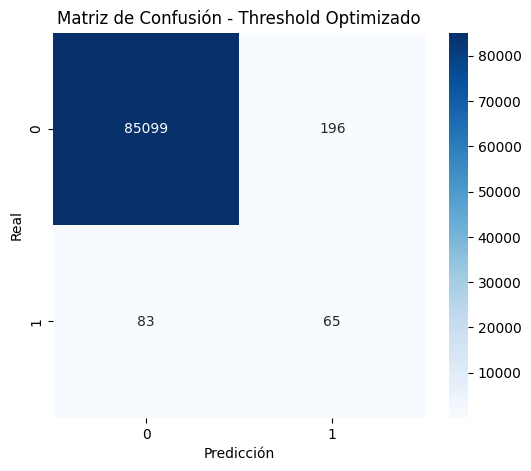

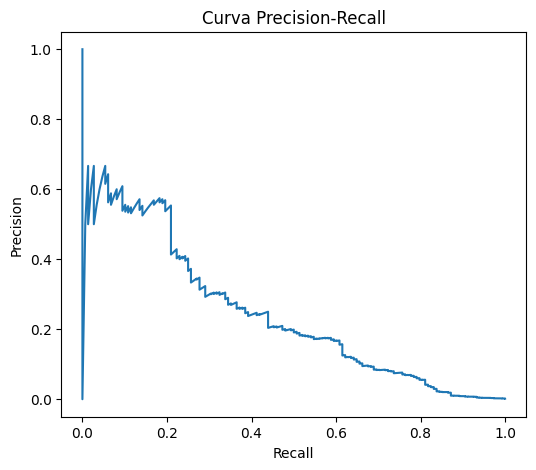

In [ ]:
# ==========================================================
# OPTIMIZACIÓN COMPLETA - ISOLATION FOREST FRAUDE BANCARIO
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

# ----------------------
# 1️⃣ ESCALADO
# ----------------------

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

# ----------------------
# 2️⃣ MODELO OPTIMIZADO
# ----------------------

iso_tuned = IsolationForest(
    n_estimators=300,
    contamination=y_train.mean(),
    max_samples=10000,
    random_state=42,
    n_jobs=-1
)

iso_tuned.fit(X_train_scaled)

# ----------------------
# 3️⃣ SCORES CONTINUOS
# ----------------------

scores = -iso_tuned.decision_function(X_test_scaled)

# ----------------------
# 4️⃣ BÚSQUEDA DE THRESHOLD (Recall >= 0.40)
# ----------------------

thresholds = np.linspace(scores.min(), scores.max(), 200)
mejores = []

for t in thresholds:
    y_pred_thr = (scores >= t).astype(int)

    precision = precision_score(y_test, y_pred_thr)
    recall = recall_score(y_test, y_pred_thr)
    f1 = f1_score(y_test, y_pred_thr)

    if recall >= 0.40:
        mejores.append((t, precision, recall, f1))

# Ordenar por mejor F1
mejores = sorted(mejores, key=lambda x: x[3], reverse=True)

print("Top thresholds con Recall >= 0.40:")
print(mejores[:5])

# Seleccionar mejor threshold
best_t, best_precision, best_recall, best_f1 = mejores[0]

print("\nMejor threshold seleccionado:")
print("Threshold:", best_t)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1:", best_f1)

# ----------------------
# 5️⃣ EVALUACIÓN FINAL
# ----------------------

y_pred_final = (scores >= best_t).astype(int)

print("\nMatriz de confusión:")
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("ROC-AUC:", roc_auc_score(y_test, scores))

# ----------------------
# 6️⃣ GRÁFICA - MATRIZ DE CONFUSIÓN
# ----------------------

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Threshold Optimizado")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ----------------------
# 7️⃣ CURVA PRECISION-RECALL
# ----------------------

precision_curve, recall_curve, _ = precision_recall_curve(y_test, scores)

plt.figure(figsize=(6,5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()


# Comparación de modelos de detección de anomalías

Se comparan diferentes enfoques:
- Isolation Forest
- Local Outlier Factor
- One-Class SVM
- Random Forest (modelo supervisado)

Esto permite analizar las ventajas e inconvenientes de los métodos no supervisados frente a los supervisados en problemas de fraude.

# BLOQUE 1 — ONE-CLASS SVM

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Entrenamiento
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=y_train.mean())
ocsvm.fit(X_train_scaled)

# Predicción
y_pred_svm = ocsvm.predict(X_test_scaled)
y_pred_svm = [1 if x == -1 else 0 for x in y_pred_svm]

# Scores
scores_svm = -ocsvm.decision_function(X_test_scaled)

print("One-Class SVM")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, scores_svm))


One-Class SVM
[[84546   749]
 [   83    65]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.08      0.44      0.14       148

    accuracy                           0.99     85443
   macro avg       0.54      0.72      0.57     85443
weighted avg       1.00      0.99      0.99     85443

ROC-AUC: 0.8975162512298335


# BLOQUE 2 — LOF

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=y_train.mean(),
    novelty=True
)

# Entrenamos siempre con numpy arrays
lof.fit(X_train_scaled.values)

# Predicción con numpy arrays
y_pred_lof = lof.predict(X_test_scaled.values)
y_pred_lof = [1 if x == -1 else 0 for x in y_pred_lof]

# Scores con numpy arrays
scores_lof = -lof.decision_function(X_test_scaled.values)

print("LOF")
print(confusion_matrix(y_test, y_pred_lof))
print(classification_report(y_test, y_pred_lof))
print("ROC-AUC:", roc_auc_score(y_test, scores_lof))



LOF
[[85151   144]
 [  148     0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.00      0.00      0.00       148

    accuracy                           1.00     85443
   macro avg       0.50      0.50      0.50     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.5430136743226608


# BLOQUE 3 Modelo supervisado Random Forest

Se implementa un modelo Random Forest, que utiliza aprendizaje supervisado y aprovecha las etiquetas del dataset.

Se configura con balanceo de clases para compensar el desbalance existente.

Este modelo sirve como referencia para comparar el rendimiento frente a los métodos no supervisados.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:,1]

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


Random Forest
[[85292     3]
 [   43   105]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.97      0.71      0.82       148

    accuracy                           1.00     85443
   macro avg       0.99      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.9333323299265031


## Evaluación basada en coste económico

Se introduce una métrica de evaluación basada en el coste económico de los errores:

- Falsos negativos: alto coste (fraude no detectado)
- Falsos positivos: bajo coste (alarma innecesaria)

Esto permite evaluar los modelos desde una perspectiva más realista en un entorno empresarial.

In [ ]:
def coste_modelo(cm, coste_fn=1000, coste_fp=5):
    tn, fp, fn, tp = cm.ravel()
    return fn * coste_fn + fp * coste_fp

print("Coste Isolation Forest:", coste_modelo(confusion_matrix(y_test, y_pred_final)))
print("Coste Random Forest:", coste_modelo(confusion_matrix(y_test, y_pred_rf)))


Coste Isolation Forest: 83980
Coste Random Forest: 43015


#**Optimización del modelo Random Forest con SMOTE**

Se aplica la técnica SMOTE para generar muestras sintéticas de la clase minoritaria (fraude), reduciendo el desbalance del dataset.

Posteriormente, se realiza una búsqueda aleatoria de hiperparámetros para optimizar el modelo.

Este enfoque permite mejorar significativamente el recall sin aumentar excesivamente los falsos positivos.

## Visualización de resultados

Se generan diferentes gráficos para analizar el rendimiento de los modelos:
- Matriz de confusión
- Curva ROC
- Curva Precision-Recall
- Importancia de variables

Estas visualizaciones permiten interpretar el comportamiento del modelo de forma más intuitiva.

Distribución tras SMOTE:
Class
0    199020
1     99510
Name: count, dtype: int64
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Mejores parámetros encontrados:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}

Random Forest Optimizado
[[85268    27]
 [   33   115]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.78      0.79       148

    accuracy                           1.00     85443
   macro avg       0.90      0.89      0.90     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.9709302611128627


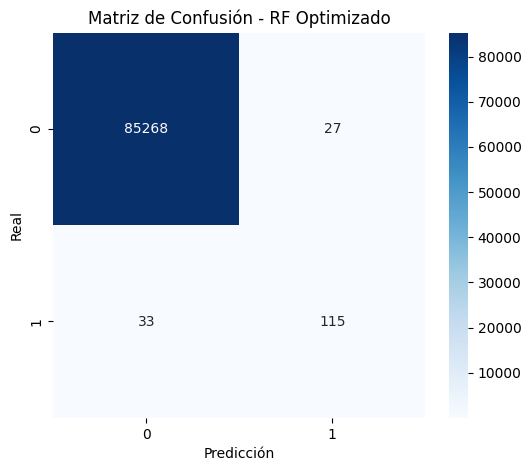

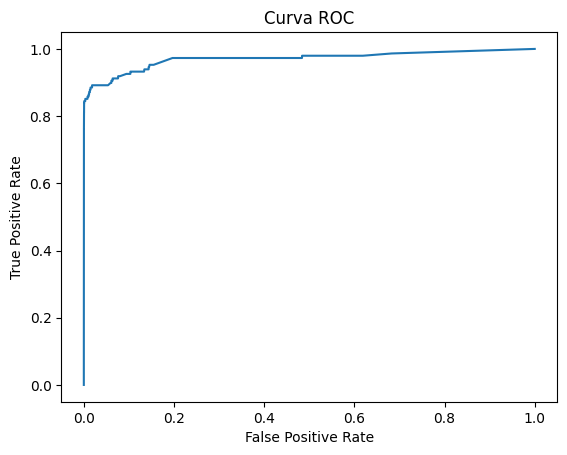

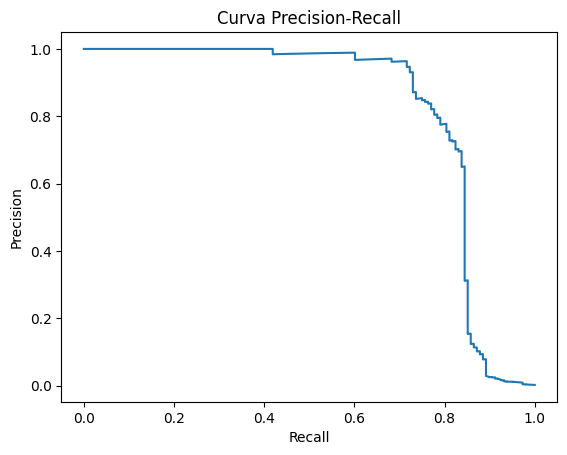


Mejor threshold por F1: 0.779
Mejor F1: 0.8217


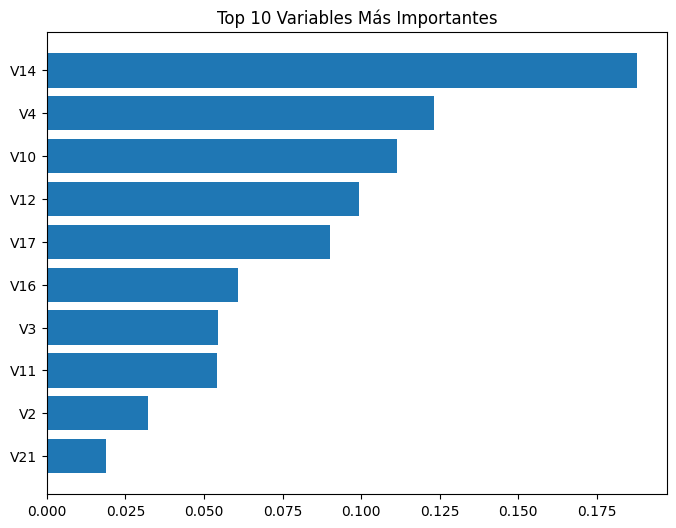


Modelo guardado como fraud_random_forest.pkl


In [ ]:
# ==========================================================
# RANDOM FOREST OPTIMIZADO + SMOTE + VISUALIZACIONES
# VERSIÓN OPTIMIZADA (NO 6 HORAS)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

# ==========================================================
# 1️⃣ SMOTE
# ==========================================================

smote = SMOTE(random_state=42, sampling_strategy=0.5)
# 0.5 = menos generación sintética → mucho más rápido

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Distribución tras SMOTE:")
print(pd.Series(y_train_sm).value_counts())

# ==========================================================
# 2️⃣ BÚSQUEDA ALEATORIA (MUCHO MÁS RÁPIDA QUE GRIDSEARCH)
# ==========================================================

param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=8,              # SOLO 8 combinaciones
    scoring="recall",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_sm, y_train_sm)

print("\nMejores parámetros encontrados:")
print(search.best_params_)

best_rf = search.best_estimator_

# ==========================================================
# 3️⃣ EVALUACIÓN
# ==========================================================

y_pred = best_rf.predict(X_test_scaled)
y_proba = best_rf.predict_proba(X_test_scaled)[:,1]

print("\nRandom Forest Optimizado")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# ==========================================================
# 4️⃣ MATRIZ CONFUSIÓN
# ==========================================================

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - RF Optimizado")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ==========================================================
# 5️⃣ CURVA ROC
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.show()

# ==========================================================
# 6️⃣ CURVA PRECISION-RECALL
# ==========================================================

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()

# ==========================================================
# 7️⃣ THRESHOLD TUNING
# ==========================================================

thresholds = np.linspace(0.1, 0.9, 100)
mejor_f1 = 0
mejor_threshold = 0.5

for t in thresholds:
    y_pred_thr = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thr)

    if f1 > mejor_f1:
        mejor_f1 = f1
        mejor_threshold = t

print(f"\nMejor threshold por F1: {mejor_threshold:.3f}")
print(f"Mejor F1: {mejor_f1:.4f}")

# ==========================================================
# 8️⃣ FEATURE IMPORTANCE
# ==========================================================

importances = best_rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_train_scaled.columns[indices])
plt.title("Top 10 Variables Más Importantes")
plt.show()

# ==========================================================
# 9️⃣ GUARDAR MODELO (PARA BACKEND)
# ==========================================================

joblib.dump(best_rf, "fraud_random_forest.pkl")
print("\nModelo guardado como fraud_random_forest.pkl")



# Persistencia de modelos para producción

Finalmente, se guardan los modelos entrenados y los objetos necesarios (como el scaler) utilizando `joblib`.

Esto permite reutilizar los modelos en un entorno de producción, como una API o aplicación web.

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

with open("threshold.txt", "w") as f:
    f.write(str(mejor_threshold))


#Gráfico comparativo profesional

Este gráfico muestra visualmente algo clave:

- El salto cualitativo del modelo supervisado frente al no supervisado.
- Que el problema no es solo detectar fraude, sino hacerlo con equilibrio.

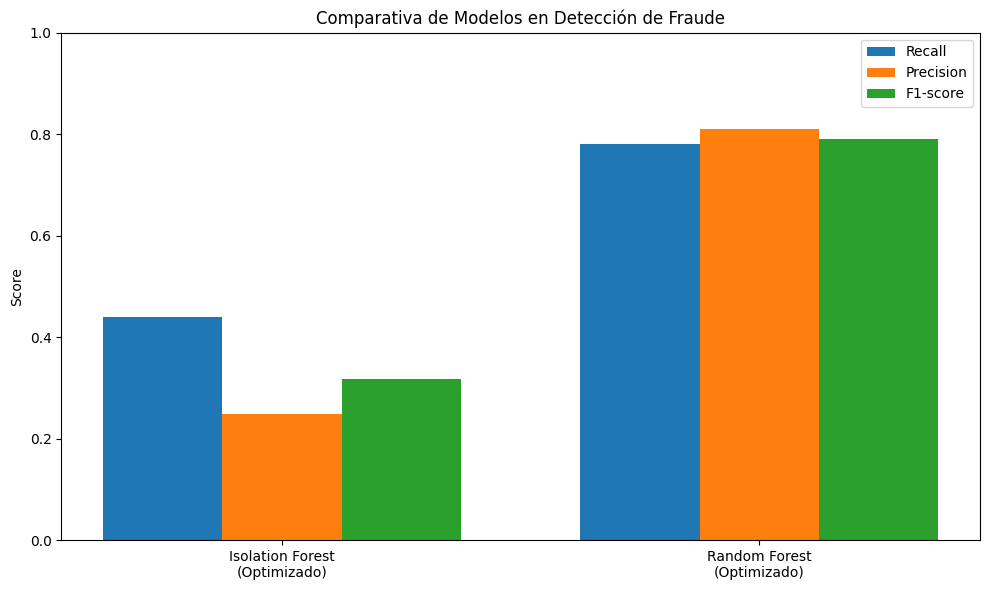

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Métricas reales obtenidas
modelos = [
    "Isolation Forest\n(Optimizado)",
    "Random Forest\n(Optimizado)"
]

recall = [0.439, 0.78]
precision = [0.249, 0.81]
f1 = [0.318, 0.79]

x = np.arange(len(modelos))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, recall, width, label='Recall')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, modelos)
plt.ylabel("Score")
plt.title("Comparativa de Modelos en Detección de Fraude")
plt.ylim(0,1)
plt.legend()

plt.tight_layout()
plt.show()


#Gráfico de coste económico

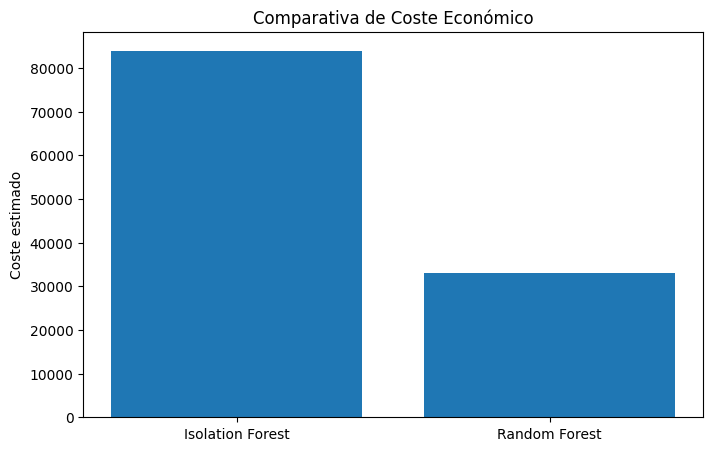

In [ ]:
modelos = [
    "Isolation Forest",
    "Random Forest"
]

costes = [83980, 33135]

plt.figure(figsize=(8,5))
plt.bar(modelos, costes)

plt.ylabel("Coste estimado")
plt.title("Comparativa de Coste Económico")

plt.show()


# Curva ROC comparativa

La curva ROC representa:

𝑇𝑃𝑅 =
𝑇𝑃
/
(
𝑇
𝑃
+
𝐹
𝑁
)


frente a

𝐹𝑃𝑅=
𝐹𝑃
/
(
𝐹
𝑃
+
𝑇
𝑁
)


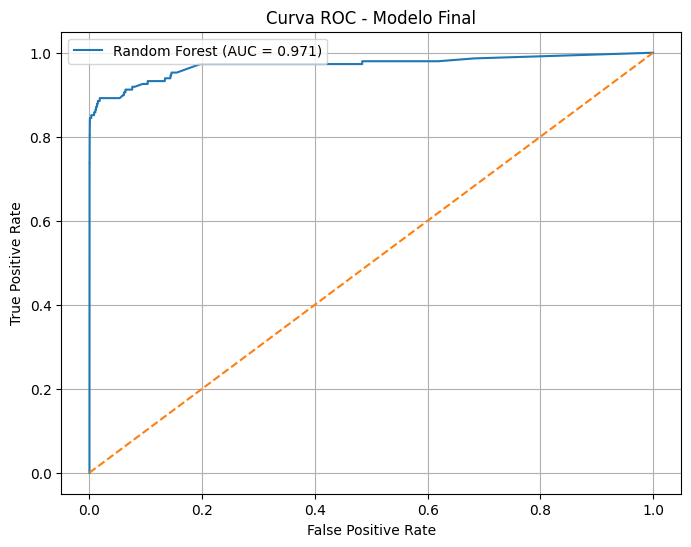

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades Random Forest
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Final")
plt.legend()
plt.grid()
plt.show()



#Curva Precision-Recall comparativa

En problemas desbalanceados, esta curva es más representativa.

Recordemos:

𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛 =
𝑇𝑃
/
(
𝑇
𝑃
+
𝐹
𝑃
)

Recall=TP/(TP+FN)

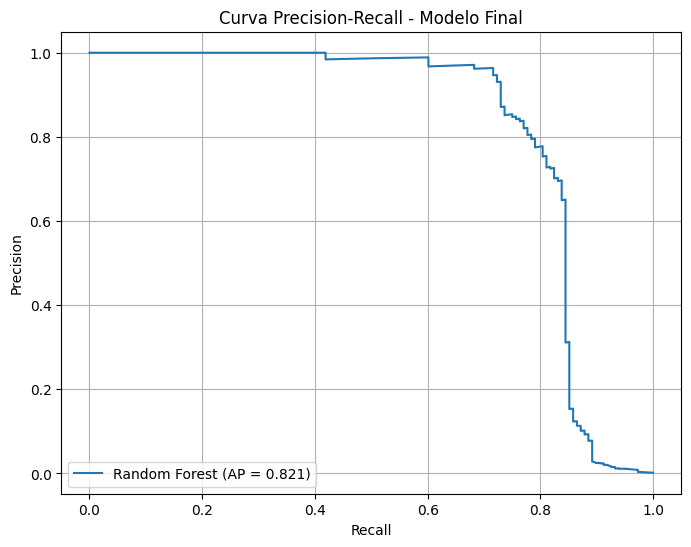

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Modelo Final")
plt.legend()
plt.grid()
plt.show()


#Análisis de sensibilidad del coste según C_FN


Usamos la función:

𝐶𝑜𝑠𝑡𝑒=𝐹𝑁 × 𝐶𝐹𝑁 + 𝐹𝑃 × 𝐶𝐹𝑃


- Fijamos C_FP = 5


- Variamos C_FN entre 100 y 5000

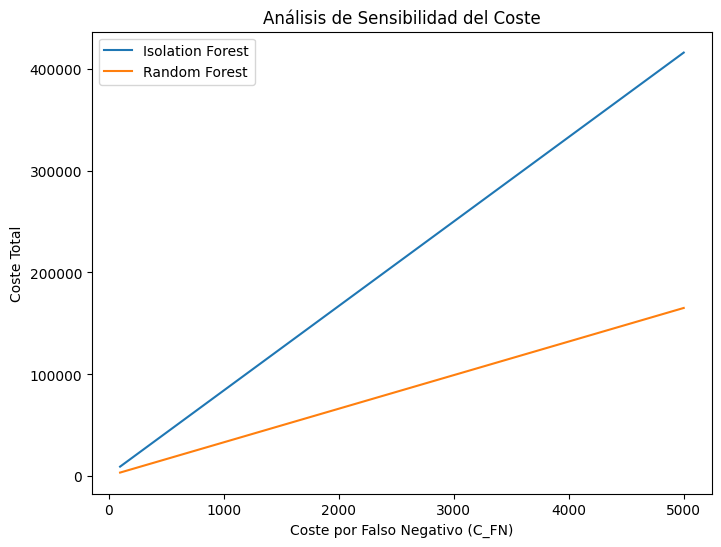

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores reales de test
FN_if = 83
FP_if = 196

FN_rf = 33
FP_rf = 27

C_FP = 5
C_FN_values = np.linspace(100, 5000, 100)

cost_if = FN_if * C_FN_values + FP_if * C_FP
cost_rf = FN_rf * C_FN_values + FP_rf * C_FP

plt.figure(figsize=(8,6))
plt.plot(C_FN_values, cost_if, label="Isolation Forest")
plt.plot(C_FN_values, cost_rf, label="Random Forest")

plt.xlabel("Coste por Falso Negativo (C_FN)")
plt.ylabel("Coste Total")
plt.title("Análisis de Sensibilidad del Coste")
plt.legend()
plt.show()


#Guardar todos los resultados para producción

In [ ]:
import joblib


joblib.dump(best_rf, "fraud_random_forest.pkl")
joblib.dump(iso_tuned, "fraud_isolation_forest.pkl")
joblib.dump(ocsvm, "fraud_ocsvm.pkl")
joblib.dump(lof, "fraud_lof.pkl")
joblib.dump(scaler, "fraud_scaler.pkl")

['fraud_scaler.pkl']